## ddHodge at toggle-switch

reproduce the results in Figure 4C,D of [Dynamo paper](https://doi.org/10.1016/j.cell.2021.12.045), and compare them to ddHodge.

## Setup

### Packages and functions

In [1]:
using GLMakie, LinearAlgebra 
using ForwardDiff: jacobian, derivative
using StatsBase: mean, median, msd, rmsd, quantile

# Toggle switch system (same params. as Dynamo)
function toggleswitch(x;k=[0.5,0.5],a=[1,1],b=[1,1],n=4)
    [
         a[1]*x[1]^n/(k[1]^n+x[1]^n)+b[1]*k[1]^n/(k[1]^n+x[2]^n)-x[1],
         a[2]*x[2]^n/(k[2]^n+x[2]^n)+b[2]*k[2]^n/(k[2]^n+x[1]^n)-x[2]
    ]
 end

Jf(x) = jacobian(toggleswitch,x) # analytical Jacobian

Jf (generic function with 1 method)

### Makie theme

In [2]:
if false
    # for figure: white BG, vector graphics
    import CairoMakie
    CairoMakie.activate!(type="svg")
    linecolor = :black
    set_theme!( 
        theme_minimal(),fontsize=14,fonts=(;regular="Helvetica"),
        Axis=(xticksvisible=true,yticksvisible=true,)
    )
else
    # for daily use: dark BG, raster graphics
    using GLMakie
    GLMakie.activate!(px_per_unit=1)
    linecolor = :black
    set_theme!(
        theme_black(),
        backgroundcolor=RGBf([40,42,54]/255...),
        Colorbar = (spinewidth=0,),
        Legend = (backgroundcolor=:transparent,framevisible=false)
    )
end
#Makie.theme(:fonts)
Makie.inline!(true)

true

## Load data

Generated results (saved as .h5ad) according to `fig1.ipynb` in [dynamo_submission](https://github.com/aristoteleo/dynamo_submission/tree/master)

In [3]:
import Muon
h5file = "../data/dynamo_toggle.h5ad"
adata = Muon.readh5ad(h5file,backed=false)
fieldnames(typeof(adata))

(:file, :X, :obs, :obs_names, :var, :var_names, :obsm, :obsp, :varm, :varp, :layers, :uns)

In [4]:
X = adata.obsm["X_pca"]'
V = adata.obsm["velocity_pca"]'
pts = Point2f.(eachcol(X))
Jana = eachslice(adata.uns["jacobian_true"]["jacobian"],dims=3)
@assert all(norm.(Jf.(eachcol(X)) .- Jana) .< 1e-8) # analytical values should be same
Jdyn = eachslice(adata.uns["jacobian_umap"]["jacobian"],dims=3)
N = length(pts)

5000

## Run ddHodge

In [ ]:
using ddHodge
g, kdtree = kNNGraph(X,6)
ddh = ddHodgeWorkflow(g,X,V,λ=0.1,ϵ=0.1,ssa=true)

[ Info: (1/4) Potential estimation
[ Info: ... done in 0.513 sec.
[ Info: (2/4) Tangent space estimation
[ Info: Consistency of orientations: 1.0
[ Info: ... done in 1.24 sec.
[ Info: (3/4) Hessian matrix estimation
[ Info: ... done in 2.685 sec.
[ Info: (4/4) Jacobian matrix estimation
[ Info: Consistency of orientations (plane): 1.0
[ Info: ... done in 4.129 sec.


:::ddHodgge::: values over graph {5000, 17704}, dimensions: 2 -> 2 (ssa: on)

## Compare the results to Dynamo
Note: $\mathrm{div}$, $\mathrm{curl}$ and $\det J_f$ are coordinate independent

In [6]:
divana = adata.obs.analytical_div
divdyn = adata.obs.divergence_pca
rotana = adata.obs.analytical_curl
rotdyn = adata.obs.curl_pca
hcat(
    [msd(pred, divana) for pred in [divdyn,ddh.div]], # div
    [msd(pred, rotana) for pred in [rotdyn,ddh.rot]], # rot
    [msd(pred, det.(Jana)) for pred in [det.(Jdyn),det.(ddh.J)]] # detJ
)

2×3 Matrix{Float64}:
 0.114246    0.0742416   0.104982
 0.00272383  0.00266921  0.00510413

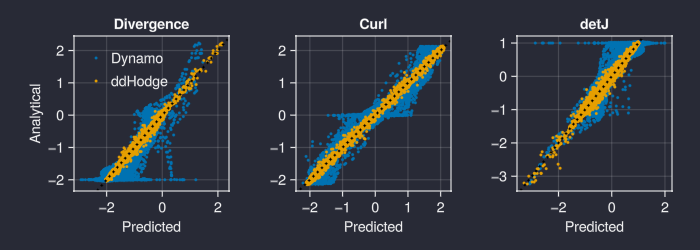

In [7]:
let ms = 4, lc = :black
    fig = Figure(size=(700,250))
    ax1 = Axis(fig[1,1],title="Divergence",xlabel="Predicted",ylabel="Analytical",aspect=1)
    ax2 = Axis(fig[1,2],title="Curl",xlabel="Predicted",aspect=1)
    ax3 = Axis(fig[1,3],title="detJ",xlabel="Predicted",aspect=1)
    pars = (;markersize=ms,rasterize=2) # shared params.
    scatter!(ax1,divdyn,divana,label="Dynamo";pars...)
    scatter!(ax1,ddh.div,divana,label="ddHodge";pars...)
    ablines!(ax1,0,1,color=lc,linestyle=:dot,linewidth=2)
    scatter!(ax2,rotdyn,rotana,;pars...)
    scatter!(ax2,ddh.rot,rotana;pars...)
    ablines!(ax2,0,1,color=lc,linestyle=:dot,linewidth=2)
    scatter!(ax3,det.(Jdyn),det.(Jana);pars...)
    scatter!(ax3,det.(ddh.J),det.(Jana);pars...)
    ablines!(ax3,0,1,color=lc,linestyle=:dot,linewidth=2)
    axislegend(ax1,position = :lt)
    linkyaxes!(ax1,ax2)
    fig
end

## ddHodge results

### Flow composition

[0.9884380498351152 0.011561950146934032]

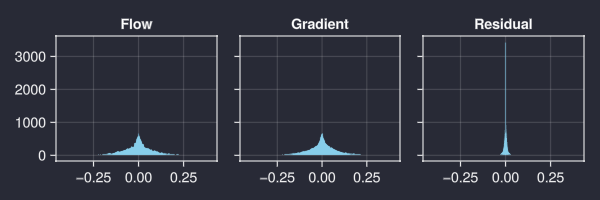

In [8]:
let
    fig = Figure(size=(600,200))
    titles = ["Flow", "Gradient", "Residual"]
    values = [ddh.w, -ddh.d0*ddh.u, ddh.w+ddh.d0*ddh.u]
    let n2s = norm.(values).^2; (n2s[2:3]/n2s[1])' end |> print
    axs = [Axis(fig[1,i],title=titles[i]) for i in 1:3]
    [hist!(axs[i], values[i], bins=200, color=:skyblue) for i in 1:3]
    [axs[i].yticklabelsvisible = false for i in 2:3]
    linkaxes!(axs...)
    fig
end

### Potential, Divergence, Curl

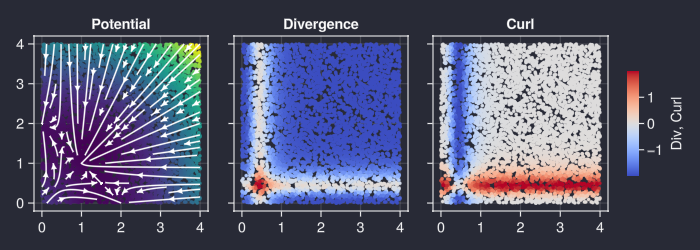

In [9]:
let ms = 5
    fig = Figure(size=(700,250))
    titles = ["Potential", "Divergence", "Curl"]
    axs = [Axis(fig[1,i],title=titles[i],aspect=1) for i in 1:3]
    scatter!(axs[1], pts, color=ddh.u, colormap=:viridis, markersize=ms, rasterize=2)
    streamplot!(
        axs[1], Point2f ∘ toggleswitch, 0..4, 0..4, gridsize=(20,20),
        linewidth=1.5, arrow_size=8.0, colormap=[:white] #Reverse(:Hiroshige)
    )
    vmax = quantile(abs.(ddh.div),0.99)
    plt = scatter!(axs[2], pts, color=ddh.div, colormap=:coolwarm, markersize=ms, colorrange=(-vmax,vmax), rasterize=2)
    scatter!(axs[3], pts, color=ddh.rot, colormap=:coolwarm, markersize=ms, colorrange=(-vmax,vmax), rasterize=2)
    [axs[i].yticklabelsvisible = false for i in 2:3]
    linkaxes!(axs...)
    Colorbar(fig[1,4],plt,height=Relative(0.6),label="Div, Curl")
    fig
end

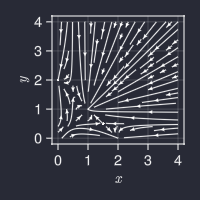

In [10]:
fig = Figure(size=(200,200))
ax = Axis(fig[1,1],xlabel=L"x",ylabel=L"y")
streamplot!(ax,
     Point2f ∘ toggleswitch, 0..4, 0..4, gridsize=(20,20), density=1.0,
     #linewidth=1.5, arrow_size=8.0, colormap=[:white], #Reverse(:Hiroshige)
     linewidth=1.0, arrow_size=5.0, colormap=[:white] #colormap=Reverse(:Hiroshige)
)
fig

### Elements of Jacobian matrix
... are the partial differentiations $\partial_x, \partial_y$ of the system (Hill eqs. in this case).

Note: The elements of $J_f$ depend on the selected coordinate.

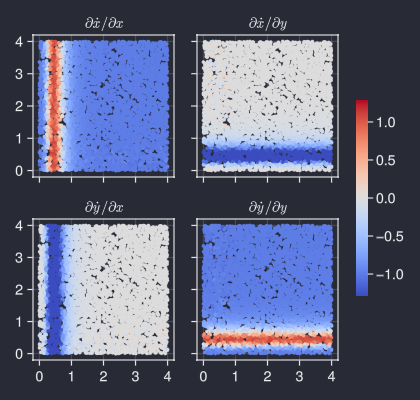

In [11]:
let ms = 5, analytical = false
    fdim = ddh.fdim
    varnames = ["x","y"]
    fmt(i,j) = L"\partial \dot{%$(varnames[i])}/\partial %$(varnames[j])"
    fig = Figure(size=(420,400))
    axs = [Axis(fig[i,j],aspect=1,title=fmt(i,j)) for i in 1:fdim, j in 1:fdim]
    vmax = quantile(vec(abs.(hcat(ddh.J...))),0.95)
    # Jacobian matrix in the canonical basis, i.e., xy coords.
    Js = analytical ? Jf.(pts) : [basischange(ddh.J[i],ddh.frames[i]) for i in 1:N]
    for i in 1:fdim, j in 1:fdim
        Jij = [J[i,j] for J in Js]
        scatter!(axs[i,j], pts, color=Jij, colormap=:coolwarm, markersize=ms, rasterize=2, colorrange=(-vmax,vmax))
    end
    [axs[i,j].yticklabelsvisible = false for i in 1:fdim for j in 2:fdim]
    [axs[i,j].xticklabelsvisible = false for i in 1:fdim-1 for j in 1:fdim]
    linkaxes!(axs...)
    Colorbar(fig[1:2,3],colormap=:coolwarm,colorrange=(-vmax,vmax),height=Relative(0.6))
    fig
end

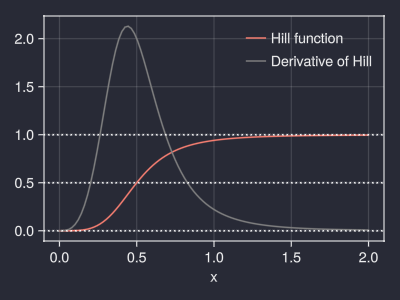

In [12]:
let k = 0.5, n=4
    xs = LinRange(0,2,100)
    f = x -> x^n/(k^n+x^n)
    f′ = x -> derivative(f,x)
    fig = Figure(size=(400,300))
    ax = Axis(fig[1,1],xlabel="x")
    lines!(xs,f.(xs),label="Hill function",color=:salmon)
    lines!(xs,f′.(xs),label="Derivative of Hill",color=:grey)
    hlines!([0,0.5,1],color=:white,linestyle=:dot)
    axislegend()
    fig
end